# Monte Carlo Markov Chain (MCMC)

Suponga una variable aleatoria $X$ con una distribución de probabilidad $f(x)$ dada por

$$f(x)=\frac{\pi(x)}{Z}$$

Donde $\pi(x)$ es una función proporcional a la distribución y $Z$ es la constante de normalización.

$$Z=\int_{\Omega} \pi(x)dx$$

En muchos casos, el cálculo de $Z$ es computacionalmente intensivo o imposible analíticamente, volviendo imposible el muestreo directo de $X$. Sin embargo, es posible generar muestras de $X$ utilizando resultados en la teoría de Cadenas de Markov y simulación por Monte Carlo.

En específico, se busca construir una cadena de Markov, con distribución estacionaria $f(x)$, que sea irreducible, aperiódica y recurrente positiva. Por el teorema ergódico, la distribución empírica de las muestras generadas convergerá a la distribución estacionaria, generando así muestras de $X$ distribuidas según $f(x)$.

Para construir la cadena, se asume que $f(x) = \frac{\pi(x)}{Z}$ es la distribución estacionaria. El objetivo es entonces construir una transición de estados $P(y|x)$ que satisfaga la condición de balance detallado:

$$f(x)P(y|x) = f(y)P(x|y)$$

Si una cadena cumple esta condición para todo par de estados $x, y$, se garantiza que $f(x)$ es su distribución estacionaria.

Sea $q(y | x)$ una función de distribución (propuesta arbitrariamente) que genera un estado candidato $y$ desde $x$. Para garantizar que la cadena cumpla con el balance detallado, se introduce una probabilidad de aceptar la transición $\alpha(x,y)$. Por lo tanto, para cualquier estado $y \neq x$, la probabilidad de transición $P(y|x)$ se define como:

$$P(y|x) = q(y|x)\alpha(x,y)$$

La probabilidad restante corresponde al rechazo de la propuesta, en cuyo caso la cadena permanece en el estado $x$. 

Sustituyendo en la ecuación de balance detallado para $y \neq x$:

$$
\begin{align*}
    f(x)P(y|x) &= f(y)P(x|y) \\
    f(x)q(y|x)\alpha(x,y) &= f(y)q(x|y)\alpha(y,x) 
\end{align*}
$$

$$\frac{\alpha(x,y)}{\alpha(y,x)} = \frac{f(y)q(x|y)}{f(x)q(y|x)} = \frac{\pi(y)q(x|y)}{\pi(x)q(y|x)}$$

Para que esta igualdad se cumpla, $\alpha(x,y)$ se define como:

$$\alpha(x,y) = \min\left\{1, \frac{\pi(y)q(x|y)}{\pi(x)q(y|x)}\right\}$$

Si $q(y|x)$ es simétrica, es decir, $q(x|y) = q(y|x)$, entonces $\alpha(x,y)$ se reduce a:

$$\alpha(x,y) = \min\left\{1, \frac{\pi(y)}{\pi(x)}\right\}$$

Para que la cadena sea irreducible, la función propuesta $q(y|x)$ debe permitir que la cadena alcance cualquier región con probabilidad positiva bajo $\pi(x)$ en un número finito de pasos. Además, la posibilidad de rechazar propuestas garantiza que la cadena sea aperiódica. Así, la cadena es ergódica, lo que asegura que su distribución límite converge a la única distribución estacionaria $f(x)$ y que se puede muestrear usando una única trayectoria tras un número suficiente de pasos iniciales.

### Algoritmo de Metropolis-Hastings

El procedimiento práctico para generar $N$ muestras de la distribución objetivo $f(x)$ utilizando la cadena de Markov descrita se resume en el siguiente algoritmo:

**Entradas:**
*   Una función $\pi(x)$ proporcional a la distribución objetivo $f(x)$.
*   Una distribución de propuesta $q(y|x)$ de la cual se pueda muestrear fácilmente.
*   Un estado inicial $x_0$ dentro del soporte de $\pi(x)$ (tal que $\pi(x_0) > 0$).
*   El número total de iteraciones $N$.

**Procedimiento:**
1. **Inicialización:** Establecer el estado actual en $x_0$.
2. **Iteración:** Para cada paso $t = 0, 1, 2, \dots, N-1$, realizar lo siguiente:
    1. **Propuesta:** Muestrear un estado candidato $y$ a partir de la distribución de propuesta condicionada al estado actual: $y \sim q(\cdot | x_t)$.
    2. **Muestreo uniforme:** Generar un número aleatorio $u$ a partir de una distribución uniforme continua en el intervalo $[0, 1]$: $u \sim \mathcal{U}(0,1)$.
    3. **Cálculo de aceptación:** Calcular la probabilidad de aceptación $\alpha(x_t, y)$ usando la regla:
       $$\alpha(x_t, y) = \min\left\{1, \frac{\pi(y)q(x_t|y)}{\pi(x_t)q(y|x_t)}\right\}$$
    4. **Decisión:** 
       * Si $u \leq \alpha(x_t, y)$, **aceptar** la propuesta y actualizar el estado: $x_{t+1} = y$.
       * Si $u > \alpha(x_t, y)$, **rechazar** la propuesta y mantener el estado actual: $x_{t+1} = x_t$.

**Salida:**
*   Una secuencia de estados $\{x_0, x_1, x_2, \dots, x_N\}$.

> **Nota sobre la convergencia:** En la práctica, las primeras $B$ iteraciones de la cadena (conocidas como periodo de *burn-in* o calentamiento) se descartan, ya que estos estados iniciales dependen fuertemente de $x_0$ y es posible que la cadena aún no haya convergido a la distribución estacionaria. Solo las muestras posteriores a $B$ se utilizan para inferencia o aproximación de la distribución original.

### Ejemplo

In [1]:
import numpy as np

In [2]:
# Funcion pi(x) (proporcional a la distribución objetivo f(x))
def pi(x):
    x_1 = x[0]
    x_2 = x[1]

    return np.exp(-(x_1**2 * x_2**2 + x_1**2 + x_2**2 - 8*x_1 - 8*x_2)/2)

x_inicial = [1.25,3.5]
N_iter = 10000
pasos = [0.1, 0.1]

x = np.zeros((2, N_iter + 1))
x[:,0] = x_inicial


for i in range(1, N_iter):
    # Generamos y ~ q(y|x) proponiendo q(y|x) como una distribucion normal
    y = x[:,i-1] + np.random.normal(0, pasos, 2)

    # Calculamos la probabilidad alpha
    alpha = pi(y) / pi(x[:,i-1]) # Como q(y|x) es simetrica, se cancela

    # Aceptamos o rechazamos la transicion
    u = np.random.uniform(0, 1)
    if u < alpha:
        x[:,i] = y
    else:
        x[:,i] = x[:,i-1]

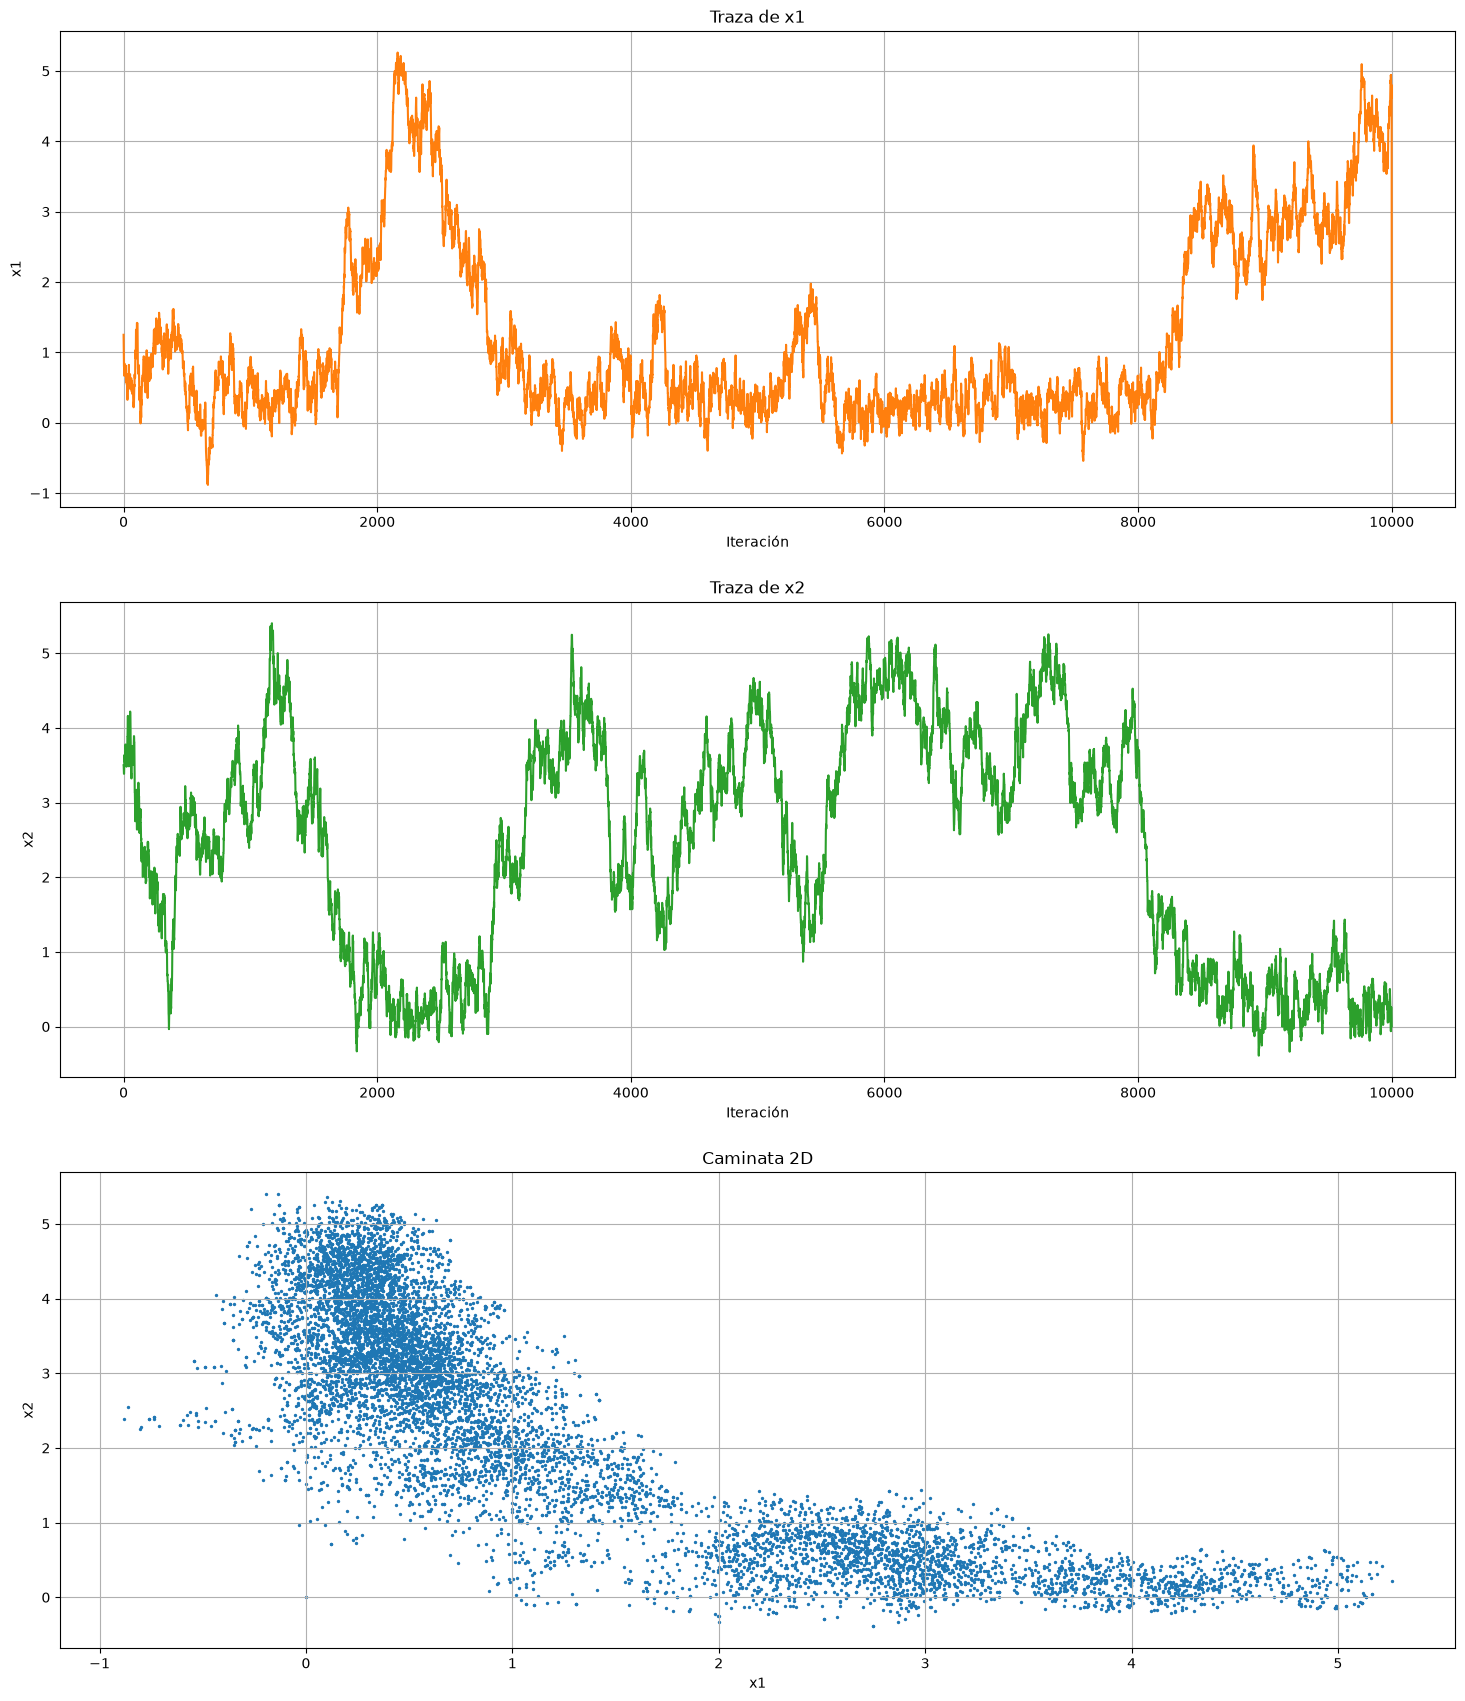

In [3]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(3,1, figsize=(18, 21))

axes[0].plot(range(len(x[0])), x[0].tolist(), color = 'tab:orange', linewidth = 1.5)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('x1')
axes[0].set_title('Traza de x1')
axes[0].grid(True)

axes[1].plot(range(len(x[1])), x[1].tolist(), color = 'tab:green', linewidth = 1.5)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('x2')
axes[1].set_title('Traza de x2')
axes[1].grid(True)

axes[2].scatter(x[0].tolist(), x[1].tolist(), color = 'tab:blue', s = 2)
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
axes[2].set_title('Caminata 2D')
axes[2].grid(True)

plt.show()